## Model Training

In [22]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler, LabelEncoder 
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.linear_model import LogisticRegression 
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC 
from sklearn.neighbors import KNeighborsClassifier 


In [7]:
df = pd.read_csv("data/personality_dataset.csv")
df.head()

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,4.0,No,4.0,6.0,No,13.0,5.0,Extrovert
1,9.0,Yes,0.0,0.0,Yes,0.0,3.0,Introvert
2,9.0,Yes,1.0,2.0,Yes,5.0,2.0,Introvert
3,0.0,No,6.0,7.0,No,14.0,8.0,Extrovert
4,3.0,No,9.0,4.0,No,8.0,5.0,Extrovert


In [8]:
df.dropna(inplace = True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2477 entries, 0 to 2899
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Time_spent_Alone           2477 non-null   float64
 1   Stage_fear                 2477 non-null   object 
 2   Social_event_attendance    2477 non-null   float64
 3   Going_outside              2477 non-null   float64
 4   Drained_after_socializing  2477 non-null   object 
 5   Friends_circle_size        2477 non-null   float64
 6   Post_frequency             2477 non-null   float64
 7   Personality                2477 non-null   object 
dtypes: float64(5), object(3)
memory usage: 174.2+ KB


### Preparing the Data

In [10]:
# Convert categorical variables to numerical
le = LabelEncoder()
df['Stage_fear'] = le.fit_transform(df['Stage_fear'])
df['Drained_after_socializing'] = le.fit_transform(df['Drained_after_socializing'])
df['Personality'] = le.fit_transform(df['Personality'])
df.head()


,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,4.0,0,4.0,6.0,0,13.0,5.0,0
1,9.0,1,0.0,0.0,1,0.0,3.0,1
2,9.0,1,1.0,2.0,1,5.0,2.0,1
3,0.0,0,6.0,7.0,0,14.0,8.0,0
4,3.0,0,9.0,4.0,0,8.0,5.0,0


In [33]:
# Separating features and target 
X = df.drop(columns = ['Personality','Stage_fear'], axis = 1)
y = df['Personality']

print("Feature data shape: ", X.shape)
print("\nTarget data shape: ", y.shape)

Feature data shape:  (2477, 6)

Target data shape:  (2477,)


In [34]:
# Splitting the data 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state= 42)

print("X_train shape: ", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test.shape: ", y_test.shape)

X_train shape:  (1981, 6)
X_test shape: (496, 6)
y_train shape: (1981,)
y_test.shape:  (496,)


In [35]:
df.select_dtypes(include= float)

,Time_spent_Alone,Social_event_attendance,Going_outside,Friends_circle_size,Post_frequency
0,4.0,4.0,6.0,13.0,5.0
1,9.0,0.0,0.0,0.0,3.0
2,9.0,1.0,2.0,5.0,2.0
3,0.0,6.0,7.0,14.0,8.0
4,3.0,9.0,4.0,8.0,5.0
...,...,...,...,...,...
2892,9.0,2.0,0.0,1.0,2.0
2895,3.0,7.0,6.0,6.0,6.0
2896,3.0,8.0,3.0,14.0,9.0
2897,4.0,1.0,1.0,4.0,0.0


In [36]:
#Scale the numerical features
scaler = StandardScaler()

numerical_columns = ['Time_spent_Alone', 'Social_event_attendance', 'Going_outside', 'Friends_circle_size', 'Post_frequency']

X_train[numerical_columns] = scaler.fit_transform(X_train[numerical_columns])
X_test[numerical_columns] = scaler.fit_transform(X_test[numerical_columns])

X_train.head(5)


,Time_spent_Alone,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency
2881,-0.132853,-1.025327,-0.461781,1,-1.229019,-0.543874
1761,-0.421430,1.386174,1.302517,0,0.846195,1.520139
2888,0.155724,-1.369828,-0.902856,1,-1.229019,-1.231879
1703,-0.710008,1.730675,0.420368,0,1.999091,0.488132
1241,-0.421430,1.386174,1.302517,0,1.307353,0.144130


In [37]:
# Function to evaluate different models

def evaluate_model(model, X_train, X_test, y_train, y_test):
    #Train the model
    model.fit(X_train, y_train)

    # Make predictions
    y_pred = model.predict(X_test)

    #print results 
    print(f"\nModel: {model.__class__.__name__}")
    print("\nClassification Report: ")
    print(classification_report(y_test, y_pred))


    #print confusion matrix 
    print("\nConfusion Matrix: ")
    print(confusion_matrix(y_test, y_pred))

    #print Accuracy 
    print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.3f}")
    
    return model, y_pred 


In [38]:
# Initialize Models
models = {
    'Random Forest': RandomForestClassifier(random_state = 42),
    'LogisticRegression': LogisticRegression(random_state = 42),
    'SVM': SVC(kernel = 'linear', random_state = 42),
    'KNN': KNeighborsClassifier()
}


results = {}
for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"Evaluating {name}")
    print('='*50)
    results[name] = evaluate_model(model, X_train, X_test, y_train, y_test)


Evaluating Random Forest

Model: RandomForestClassifier

Classification Report: 
              precision    recall  f1-score   support

           0       0.91      0.89      0.90       246
           1       0.90      0.92      0.91       250

    accuracy                           0.91       496
   macro avg       0.91      0.91      0.91       496
weighted avg       0.91      0.91      0.91       496


Confusion Matrix: 
[[220  26]
 [ 21 229]]

Accuracy: 0.905

Evaluating LogisticRegression

Model: LogisticRegression

Classification Report: 
              precision    recall  f1-score   support

           0       0.94      0.91      0.93       246
           1       0.91      0.95      0.93       250

    accuracy                           0.93       496
   macro avg       0.93      0.93      0.93       496
weighted avg       0.93      0.93      0.93       496


Confusion Matrix: 
[[223  23]
 [ 13 237]]

Accuracy: 0.927

Evaluating SVM

Model: SVC

Classification Report: 
        

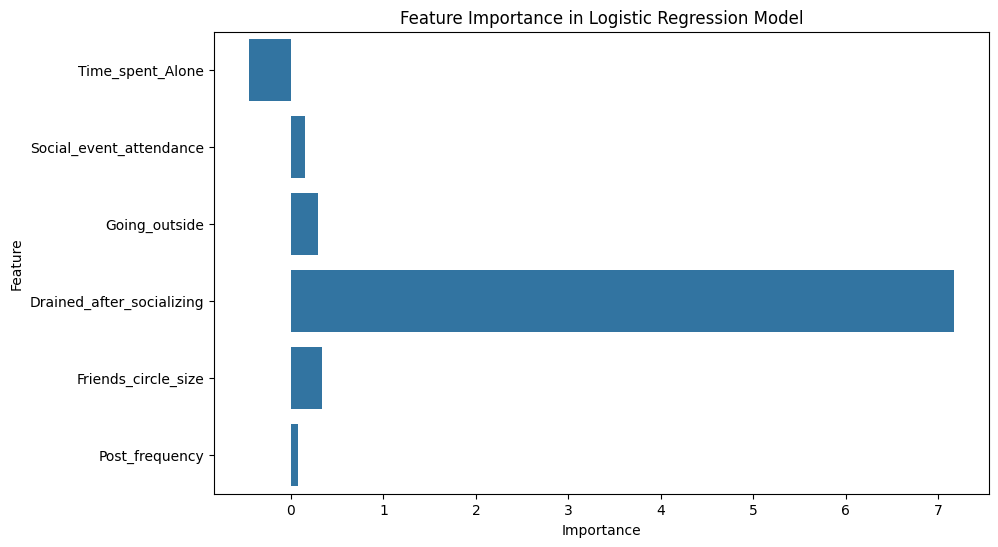

                     Feature  Importance
0           Time_spent_Alone   -0.452385
1    Social_event_attendance    0.152652
2              Going_outside    0.288375
3  Drained_after_socializing    7.166387
4        Friends_circle_size    0.336493


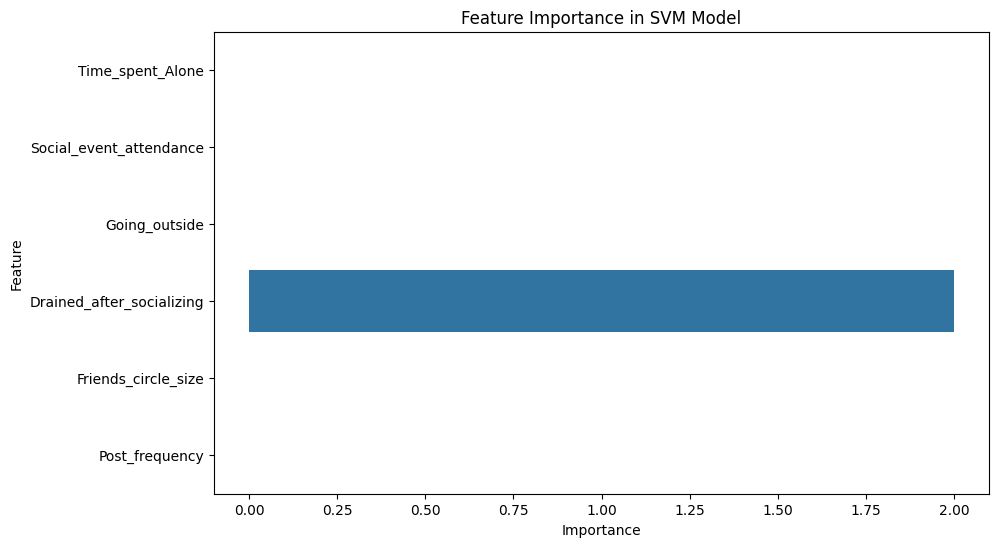

                     Feature  Importance
0           Time_spent_Alone    0.000044
1    Social_event_attendance   -0.000004
2              Going_outside    0.000033
3  Drained_after_socializing    1.999133
4        Friends_circle_size   -0.000045


In [41]:
# Analyzing feature Importance for best performing model 
# Get Feature importance from Logistic Regression
if 'LogisticRegression' in results:
    lr_model = results['LogisticRegression'][0]
    lr_feature_importance = pd.DataFrame({
        'Feature': X.columns,
        'Importance': lr_model.coef_[0]
    })
    plt.figure(figsize=(10,6))
    sns.barplot(x = 'Importance', y = 'Feature', data = lr_feature_importance)
    plt.title('Feature Importance in Logistic Regression Model')
    plt.show()
    print(lr_feature_importance.head())

if 'SVM' in results:
    SVC_model = results['SVM'][0]
    SVC_feature_importance = pd.DataFrame({
        'Feature': X.columns,
        'Importance': SVC_model.coef_[0]
    })
    plt.figure(figsize=(10,6))
    sns.barplot(x = 'Importance', y = 'Feature', data = SVC_feature_importance)
    plt.title('Feature Importance in SVM Model')
    plt.show()
    print(SVC_feature_importance.head())



In [31]:
# Make predictiosn on new data
def predict_personality(model, data):
    """ 
    Make Predictions on new data
    data:-> dictionary
    - Time_spent_Alone
    - Stage_fear
    - Social_event_attendance
    - Going_outside
    - Drained_after_socializing
    - Friends_circle_size 
    - Post_frequency
    """
    # Convert to Dataframe
    df_new = pd.DataFrame([data])

    # Converting Categorical variables
    df_new['Starge_fear'] = le.transform(df_new['Stage_fear'])
    df_new['Drained_after_socializing'] = le.transform(df_new['Drained_after_socializing'])

    # Scaling numerical features
    df_new[numerical_columns] = scaler.transform(df_new[numerical_columns])

    # Make Prediction
    prediction = model.predict(df_new)
    probability = model.predict_proba(df_new)

    return {
        'Prediction': 'Introvert' if prediction[0] == 0 else'Extrovert',
        'Confidence': max(probability[0])* 100
    }